# Numerische Mathematik mit NumPy

Das Modul `numpy` (Numerical Python) stellt effiziente Datenstrukturen und Funktionen für numerische Berechnungen in Python bereit. Es ist besonders nützlich für die Arbeit mit Vektoren und Matrizen.
## Installation
Falls `numpy` noch nicht installiert ist, kann es mit dem folgenden Befehl im VSCode Terminal installiert werden:
```bash
pip install numpy
```
__Achtung__: Wenn Sie ein `venv` (virtuelle Umgebung) verwenden, stellen Sie sicher, dass es aktiviert ist, bevor Sie den Installationsbefehl ausführen.

- im Terminal steht der Name des `venv` in Klammern, z.B. `(.venv) PS C:\Pfad\zu\Ihrem\Projekt>`
- Falls nicht, aktivieren Sie es mit dem Befehl:
    - Windows: `.venv\Scripts\activate`
    - macOS/Linux: `source .venv/bin/activate`


## NumPy Arrays
NumPy stellt die Datenstruktur `ndarray` (n-dimensional array) zur Verfügung, die effizientere Speicherung und Verarbeitung von numerischen Daten ermöglicht als die Standard-Python-Listen.
```python
array = np.array([Python-Liste], dtype = Datentyp)
```



Diese Funktion erstellt ein NumPy Array aus einer Python-Liste.
- Der optionale Parameter `dtype` gibt den Datentyp der Elemente im Array an (z.B. `int`, `float`, `complex`).
- Jeder Eintrag in einem NumPy Array hat den gleichen Datentyp (im Unterschied zu Python-Listen, die verschiedene Datentypen enthalten können). 
- Wird `dtype` nicht angegeben, wird der Datentyp automatisch bestimmt.
- Verfügbare Datentypen sind
    - `int` (Ganzzahlen)
    - `float` (Gleitkommazahlen)
    - `complex` (komplexe Zahlen)
    - `bool` (Boolesche Werte)
    - `str` (Zeichenketten)
- Numpy-Interne Datentypen sind z.B.
    - `np.float32`, `np.float64` (für Gleitkommazahlen mit einfacher bzw. doppelter Genauigkeit, später mehr dazu)
    - `np.int32`, `np.int64` (für Ganzzahlen mit einfacher bzw. doppelter Genauigkeit)
    - uvm.

Wie Listen können einzelne Elemente von `ndarray` Objekten geändert werden. Das Objekt selbst ist jedoch unveränderlich (immutable), d.h. die Größe des Arrays kann nicht geändert werden (im Gegensatz zu Listen, die dynamisch wachsen können).

In [1]:
import numpy as np
a = np.array([1, 2, 3], dtype=int)
print(a)
a[0] = 10
print(a)

[1 2 3]
[10  2  3]


### Zugriff auf NumPy Arrays
Der Zugriff auf Elemente in einem NumPy Array erfolgt ähnlich wie bei Python-Listen, jedoch mit einigen Erweiterungen:
- Einzelne Elemente können mit eckigen Klammern und dem Index angesprochen werden (Index beginnt bei 0).
- Mehrdimensionale Arrays können mit mehreren Indizes angesprochen werden, z.B. `array[i, j]` für das Element in der i-ten Zeile und j-ten Spalte.
- Slicing funktioniert ebenfalls, z.B. `array[start:stop:step]` für Teilarrays.
- Mehrdimensionales Slicing ist ebenfalls möglich, z.B. `array[0:2, 1:3]` für einen Ausschnitt eines 2D-Arrays.
- Mittels Listen kann man Teilarrays extrahieren, z.B. `array[[0, 2], [1, 3]]` für spezifische Elemente.

In [2]:
A = np.array([[1, 2, 3], [4, 5, 6]])
print(A)
print(A[0, 1])  # Zugriff auf das Element in der ersten Zeile und zweiten Spalte
print(A[0][1])  # Alternativer Zugriff
print(A[0:2, 1:3])  # Slicing
print(A[[0, 1], [1, 2]])  # Zugriff auf Teilmatrix mittels Listen
print(A[1])  # Zugriff auf die zweite Zeile gibt wieder eine NumPy Array zurück
print(A[:,2])  # Zugriff auf die dritte Spalte

[[1 2 3]
 [4 5 6]]
2
2
[[2 3]
 [5 6]]
[2 6]
[4 5 6]
[3 6]


__Zugriff mittels True/False Masken:__

In NumPy können Sie auch boolesche Masken verwenden, um auf bestimmte Elemente eines Arrays zuzugreifen. Eine boolesche Maske ist ein Array der gleichen Form wie das ursprüngliche Array, das `True` für die Elemente enthält, die Sie auswählen möchten, und `False` für die Elemente, die Sie ausschließen möchten.
- Nützlich, wenn Sie Elemente basierend auf einer Bedingung auswählen möchten
- Mehrdimensionale Arrays werden zeilenweise zu einem eindimensionalen Array "abgeflacht"

In [2]:
import numpy as np
x = np.array([1, 2, 3, 4, 5])
mask = x > 2  # Boolesche Maske erstellen
print(mask)  # Ausgabe: [False False  True  True  True]
filtered_x = x[mask]  # Zugriff auf Elemente, die der Maske entsprechen
print(filtered_x)  # Ausgabe: [3 4 5]

A = np.array([[1, 2, 3], [4, 5, 6]])
print(A[A<4])  # Boolesche Maske erstellen

[False False  True  True  True]
[3 4 5]
[1 2 3]


__Form und Dimensionen:__

- `array.shape`: Gibt die Dimensionen des Arrays als Tupel zurück.
- `array.ndim`: Gibt die Anzahl der Dimensionen des Arrays zurück.
- `array.size`: Gibt die Gesamtanzahl der Elemente im Array zurück.



Ausgehend von einem Array kann man neue Arrays mit dem selben Inhalt aber anderer Form erstellen, solange die Gesamtanzahl der Elemente gleich bleibt:
- `new_array = array.reshape(new_shape)`: Ändert die Form des Arrays.
    - `new_shape` ist ein Tupel, das die neuen Dimensionen angibt.
    - Eine Dimension kann als `-1` angegeben werden, um sie automatisch zu berechnen (die Gesamtanzahl der Elemente muss übereinstimmen).
    - Die Umformung erfolgt durch zeilenweises Auslesen des ursprünglichen Arrays und zeilenweises Füllen des neuen Arrays.
        - Das kann mit dem Argument `order` beeinflusst werden:
            - `order='C'` (Standard): Zeilenweise (C-Stil)
            - `order='F'`: Spaltenweise (Fortran-Stil)
- `array.flatten()`: Gibt eine Kopie des Arrays als eindimensionales Array zurück.
- __Achtung__: `shape = (n,)` ist ein eindimensionales Array mit `n` Elementen, während `shape = (n, 1)` ein zweidimensionales Array mit `n` Zeilen und 1 Spalte ist.

In [4]:
A = np.array([[1, 2, 3], [4, 5, 6]])
print(f"A is a {A.ndim}-dimensional array with shape {A.shape} containing {A.size} elements")
print(A)
A=A.reshape(3, 2)  # Ändert die Form des Arrays zu 3 Zeilen und 2 Spalten
print(f"A is a {A.ndim}-dimensional array with shape {A.shape} containing {A.size} elements")
print(A)
A=A.reshape(2, 3, order ='F')  # Ändert die Form des Arrays zu 2 Zeilen und 3 Spalten, Spaltenweise
print(f"A is a {A.ndim}-dimensional array with shape {A.shape} containing {A.size} elements")
print(A)
A = A.flatten()  # Macht aus einem mehrdimensionalen Array ein eindimensionales Array
print(f"A is a {A.ndim}-dimensional array with shape {A.shape} containing {A.size} elements")
print(A)


A is a 2-dimensional array with shape (2, 3) containing 6 elements
[[1 2 3]
 [4 5 6]]
A is a 2-dimensional array with shape (3, 2) containing 6 elements
[[1 2]
 [3 4]
 [5 6]]
A is a 2-dimensional array with shape (2, 3) containing 6 elements
[[1 5 4]
 [3 2 6]]
A is a 1-dimensional array with shape (6,) containing 6 elements
[1 5 4 3 2 6]


__Vordefinierte Arrays:__
- `np.zeros(shape, dtype=float)`: Erstellt ein Array der angegebenen Form, gefüllt mit Nullen.
- `np.zeros_like(array)`: Erstellt ein Array mit der gleichen Form und dem gleichen Datentyp wie das gegebene Array, gefüllt mit Nullen.
- `np.ones(shape, dtype=float)`: Erstellt ein Array der angegebenen Form, gefüllt mit Einsen.
- `np.ones_like(array)`: Erstellt ein Array mit der gleichen Form und dem gleichen Datentyp wie das gegebene Array, gefüllt mit Einsen.
- `np.full(shape, fill_value, dtype=None)`: Erstellt ein Array der angegebenen Form, gefüllt mit dem angegebenen Wert.
- `np.eye(n, dtype=float)`: Erstellt eine n x n Einheitsmatrix.
- `np.arange(start, stop, step, dtype=None)`: Erstellt ein Array mit Werten im angegebenen Bereich (ähnlich wie die eingebaute `range`-Funktion, aber gibt ein NumPy Array zurück).
- `np.linspace(start, stop, num, dtype=None)`: Erstellt ein Array mit `num` gleichmäßig verteilten Werten zwischen `start` und `stop`.
- `np.random.rand(d0, d1, ..., dn)`: Erstellt ein Array mit Dimensionen `d0, d1, ..., dn` und füllt es mit zufälligen Werten aus einer gleichverteilten Verteilung im Bereich $[0, 1)$.
- `np.random.randn(d0, d1, ..., dn)`: Erstellt ein Array mit Dimensionen `d0, d1, ..., dn` und füllt es mit zufälligen Werten aus einer Standardnormalverteilung (Mittelwert 0, Standardabweichung 1).

In [5]:
print(np.zeros((2,3)))  # 2x3 Array mit Nullen
print(np.ones((2,3)))   # 2x3 Array mit Einsen
print(np.full((2,3), 7))  # 2x3 Array mit dem Wert 7
print(np.eye(3))        # 3x3 Einheitsmatrix
print(np.arange(0, 10, 2))  # Array mit Werten von 0 bis 10 mit Schrittweite 2
print(np.linspace(0, 1, 5))  # Array mit 5 gleichmäßig verteilten Werten zwischen 0 und 1
print(np.random.rand(2,3))  # 2x3 Array mit zufälligen Werten aus [0, 1)
print(np.random.randn(2,3))  # 2x3 Array mit zufälligen Werten aus der Standardnormalverteilung

[[0. 0. 0.]
 [0. 0. 0.]]
[[1. 1. 1.]
 [1. 1. 1.]]
[[7 7 7]
 [7 7 7]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[0.74389196 0.29441823 0.1934085 ]
 [0.86677025 0.26048959 0.85568049]]
[[-0.60390814  1.0585662   0.38002227]
 [-0.05487886 -2.507997    2.23658862]]


## `NumPy`-Arrays speichern und laden
NumPy bietet Funktionen zum Speichern und Laden von Arrays in verschiedenen Formaten:
- `np.save(filename, array)`: Speichert ein Array im `.npy`-Format.
- `np.load(filename)`: Lädt ein Array aus einer `.npy`-Datei.
- `np.savetxt(filename, array, delimiter=',')`: Speichert ein Array im Textformat (z.B. CSV).
    - Der optionale Parameter `delimiter` gibt das Trennzeichen an (Standard ist ein Leerzeichen).
- `np.loadtxt(filename, delimiter=',')`: Lädt ein Array aus einer Textdatei.

In [6]:
import numpy as np
x=np.array([1, 2, 3])
np.save("data/array1.npy", x)
y=np.load("data/array1.npy")
print(y)

[1 2 3]


## 3D Plots mit Matplotlib und NumPy 
Matplotlib unterstützt auch 3D-Plots.
- Zuerst muss mit `plt.figure()` eine Figur estellt werden
- Dann wird mit `add_subplot(111, projection='3d')` eine 3D-Achse hinzugefügt
    - Der erste Parameter `111` bedeutet, dass die Figur 1 Zeile und 1 Spalte hat und der Subplot an Position 1 ist
- anstatt den Subplot mit `subplot()` zu aktivieren, müssen wir Methoden der 3D-Achse verwenden
- `plot_surface()` wird verwendet, um eine 3D-Oberfläche zu plotten
- `cmap` steuert die Farbcodierung der Oberfläche
    - es gibt viele verschiedene Colormaps, z.B. 'viridis', 'plasma', 'inferno', 'magma', 'cividis', etc.
- `edgecolor='none'` entfernt die Kantenlinien der Oberfläche für eine glattere Darstellung
- `view_init(elev, azim)` ändert die Perspektive der 3D-Darstellung
    - `elev` ist der Höhenwinkel (Elevation) in Grad
    - `azim` ist der Azimutwinkel (Winkel zwischen x-Achse und der Blickrichtung) in Grad

Die Daten für den Surface-Plot müssen in einem Gitter vorliegen. Dies kann mit `numpy.meshgrid()` erreicht werden.
- `meshgrid()` erstellt zwei 2D-Arrays, die die x- und y-Koordinaten eines Gitters repräsentieren
- mit Inputs `X = [1,2,3]` und `Y = [4,5]` wird z.B. folgendes Gitter erstellt:
```python
X = [[1,2,3],
     [1,2,3]]
 Y = [[4,4,4],
     [5,5,5]]
```

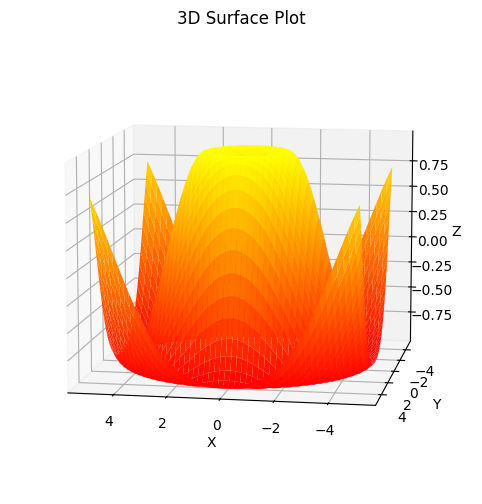

In [14]:
import numpy as np
import matplotlib.pyplot as plt
X = np.linspace(-5, 5, 50)
Y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='autumn',edgecolor = 'none')
ax.set_title('3D Surface Plot')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(10, 100) 
plt.show()


### Beispiel: Plot des Sonnensystems mit Copilot
Bei komplizierteren Plots lohnt sich oft der Einsatz von KI. Auch wenn das Ergebnis nicht immer perfekt ist, kann man es oft als guten Ausgangspunkt verwenden und dann weiter anpassen.
Der folgende Code wurde mit dem Prompt "Create a 3d Plot of the solar system with the sun, earth and moon" erstellt.

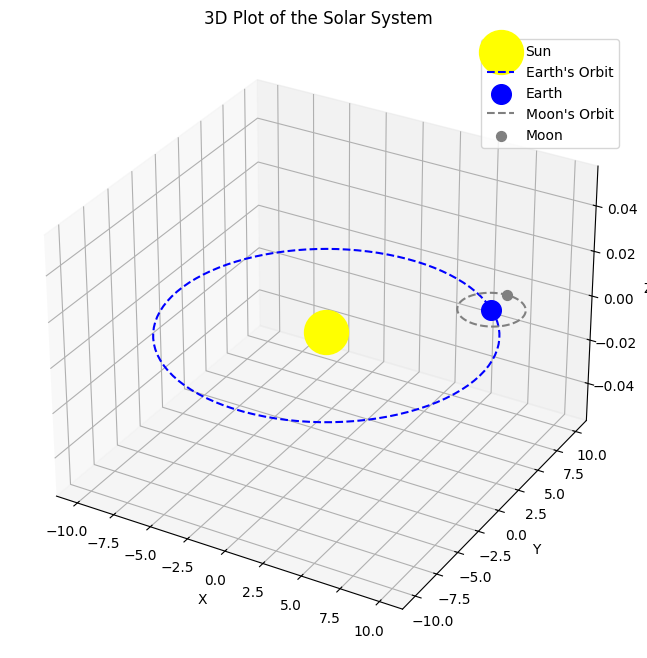

In [8]:
# Create a new figure
fig_solar = plt.figure(figsize=(8, 8))
ax_solar = fig_solar.add_subplot(111, projection='3d')

# Plot the Sun
ax_solar.scatter(0, 0, 0, color='yellow', s=1000, label='Sun')  # Sun at the origin

# Plot the Earth's orbit
earth_orbit_radius = 10
theta = np.linspace(0, 2 * np.pi, 100)
earth_orbit_x = earth_orbit_radius * np.cos(theta)
earth_orbit_y = earth_orbit_radius * np.sin(theta)
earth_orbit_z = np.zeros_like(theta)
ax_solar.plot(earth_orbit_x, earth_orbit_y, earth_orbit_z, color='blue', linestyle='--', label="Earth's Orbit")

# Plot the Earth
earth_position = (earth_orbit_radius * np.cos(np.pi / 4), earth_orbit_radius * np.sin(np.pi / 4), 0)
ax_solar.scatter(*earth_position, color='blue', s=200, label='Earth')

# Plot the Moon's orbit around the Earth
moon_orbit_radius = 2
moon_theta = np.linspace(0, 2 * np.pi, 100)
moon_orbit_x = earth_position[0] + moon_orbit_radius * np.cos(moon_theta)
moon_orbit_y = earth_position[1] + moon_orbit_radius * np.sin(moon_theta)
moon_orbit_z = np.zeros_like(moon_theta)
ax_solar.plot(moon_orbit_x, moon_orbit_y, moon_orbit_z, color='gray', linestyle='--', label="Moon's Orbit")

# Plot the Moon
moon_position = (earth_position[0] + moon_orbit_radius * np.cos(np.pi / 2),
                 earth_position[1] + moon_orbit_radius * np.sin(np.pi / 2),
                 0)
ax_solar.scatter(*moon_position, color='gray', s=50, label='Moon')

# Set labels and title
ax_solar.set_title('3D Plot of the Solar System')
ax_solar.set_xlabel('X')
ax_solar.set_ylabel('Y')
ax_solar.set_zlabel('Z')
ax_solar.legend()

plt.show()

## Views (Ansichten) von NumPy Arrays
NumPy unterstützt das Konzept der "Views" (Ansichten), bei dem mehrere Variablen auf dasselbe Array im Speicher verweisen können. 
- Änderungen an einer View wirken sich auf das Originalarray aus und umgekehrt. 
- Der Unterschied zu normalen Variablenzuweisungen von `mutable` Objekten (wie Listen) ist, dass bei Views die Elemente des Arrays verschieden interpretiert werden können (z.B. andere Form oder nur ein Teil der Daten).
- Dieses Verhalten ist nützlich, um Speicherplatz zu sparen und die Leistung zu verbessern, da keine Kopien der Daten erstellt werden müssen.

Syntax:
```python
view = array.view()
```
- Das direkte verwenden von `view()` oft nicht nötig, da viele Operationen automatisch eine View zurückgeben, z.B. 
    - Slicing
    - `reshape()`


In [9]:
a = np.arange(1,1000,2)
b = a[0:10] # erzeugt einen View auf die ersten 10 Elemente von a
print(b)
b[0] = 100
print(a[0])  # a wurde auch geändert, da b ein View ist

c = a.reshape((10,50))  # erzeugt einen View auf a mit neuer Form
print(c.shape)
c[0,1] = 200
print(a[1])  # a wurde auch geändert, da c ein View ist

[ 1  3  5  7  9 11 13 15 17 19]
100
(10, 50)
200


### Kopien von NumPy Arrays

- `copy = array.copy()`: Erstellt eine echte Kopie des Arrays im Speicher.
- Änderungen an der Kopie wirken sich nicht auf das Originalarray aus und umgekehrt.
    - nicht das selbe wie `copy.copy()` oder `copy.deepcopy()` aus dem Modul `copy`, da diese auch bei normalen Python-Listen verwendet werden können.
- Kopien von großen Arrays können teuer sein (allerdings erst ab tausenden oder millionen Elementen relevant).

In [10]:
a = np.ones((3,3))
b = a.copy()  # erzeugt eine Kopie von a
b[0,0] = 100
print(a[0,0])  # a wurde nicht geändert, da b eine Kopie ist
print(b[0,0])  # b wurde geändert

1.0
100.0


### Beispiel für Views und Kopien
Folgende Illustration skizziert die Beziehung zwischen Originalarray, Shallow-Kopie, View und echter (Deep) Kopie

<img src="illustrations/views.png" style="width:400px;" >

Hier ist:
- `A` das Original Array
- `B` eine Shallow-Kopie von `A` (z.B. durch Zuweisung `B = A`)
    - `A` und `B` teilen sich die Array-Struktur (Shape, Datentyp, etc.) und die Daten
- `C` eine View auf `A` (z.B. `C=A.reshape(6,1)`)
    - `A` und `C` teilen sich die Daten, aber interpretieren diese Daten durch unterschiedliche Array-Strukturen (in diesem Fall unterschiedliche Formen)
- `D` eine echte Kopie von `A` (z.B. `D=A.copy()`)
    - `A` und `D` sind komplett unabhängig, Änderungen an einem Array wirken sich nicht auf das andere aus

In [5]:
import numpy as np
A = np.array([[1, 2, 3], [4, 5, 6]])
B = A
C = A.reshape(6, 1)
D = A.copy()

D[0,0] = 100
print(A) # A wurde nicht geändert, da D eine Kopie ist
C[0,0] = 200
print(A) # A wurde auch geändert, da C ein View ist
B[0,0] = 300
print(A) # A wurde auch geändert, da B nur ein anderer Name für A ist

[[1 2 3]
 [4 5 6]]
[[200   2   3]
 [  4   5   6]]
[[300   2   3]
 [  4   5   6]]


### Unterscheiden zwischen Views und Kopien
Man kann überprüfen, ob ein Array eigentlich ein `View` ist indem man die `base` Eigenschaft des Arrays überprüft:
- Ist `array.base` `None`, dann ist `array` kein View, sondern ein Originalarray oder eine echte Kopie.
- Ist `array.base` nicht `None`, dann ist `array` ein View und `array.base` verweist auf das Originalarray, auf dem der View basiert.

In [16]:
A = np.array([[1, 2, 3], [4, 5, 6]])
B = A
C = A[:2,:2]
D = A.copy()
print(B.base, B is A)  # None, da B kein View ist, True, da B nur ein anderer Name für A ist
print(C)
print(C.base, C is A)  # A, da C ein View auf A ist, False, da C nicht A ist
print(D.base, D is A)  # None, da D eine Kopie ist, False, da D nicht A ist

None True
[[1 2]
 [4 5]]
[[1 2 3]
 [4 5 6]] False
None False
